In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scanpy.external as sce
from scipy.spatial.distance import cdist
import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
# h5ad built in Hematokytos/figure3/timeseries_integration.ipynb
fpath = "/scratch/indikar_root/indikar1/shared_data/parse/anndata/scfib_hsc_parse_integration.h5ad"

adata = sc.read_h5ad(fpath)

adata.uns['phase_colors'] = ['#ad3803', '#56b567', 'gold']
adata.uns['group_label_colors'] = ['#023eff', '#ff7c00', '#1ac938', '#e8000b', '#8b2be2', '#9f4800', '#f14cc1', '#a3a3a3', '#ffc400']
# sns.color_palette("bright", n_colors=9).as_hex()

adata

CPU times: user 339 ms, sys: 1.73 s, total: 2.06 s
Wall time: 13.3 s


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', '

In [3]:
display(adata.obs['group_label'].value_counts())

group_label
Control     7842
R2          4343
R1          1982
D14         1973
D7          1529
spike-in    1508
D21         1331
R3           524
D0           459
Name: count, dtype: int64

# embedding

2026-08-07 11:55:17 | [INFO] init


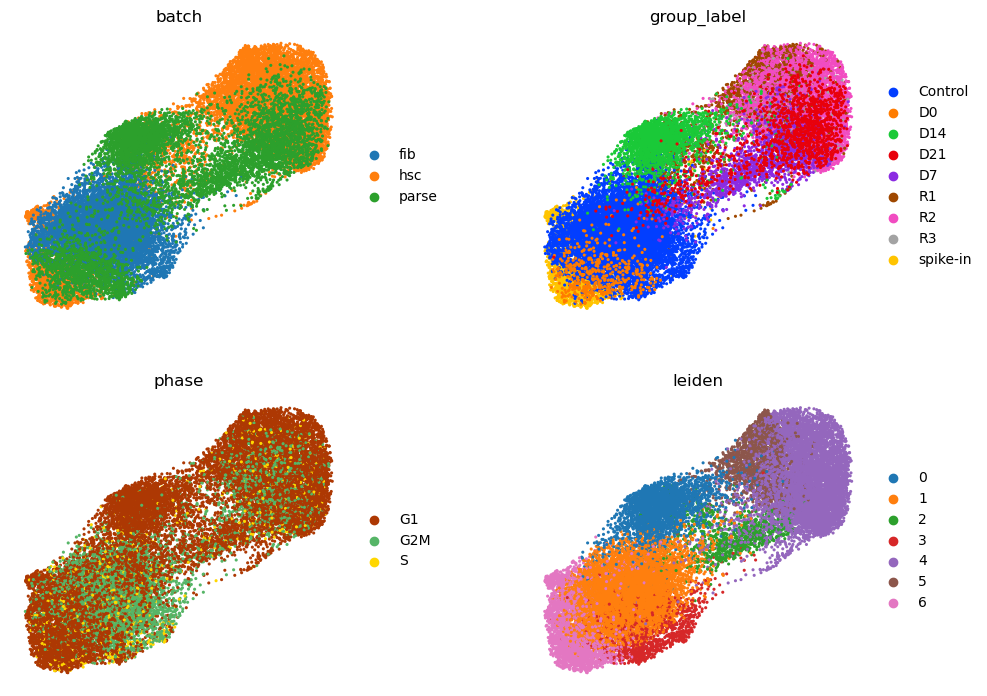

In [4]:
rsc.get.anndata_to_GPU(adata)

rsc.pp.neighbors(
    adata, 
    use_rep='X_scANVI_cc_covar',
    n_neighbors=35,
)

rsc.tl.draw_graph(adata)

rsc.tl.leiden(
    adata,
    resolution=0.5,
)

rsc.get.anndata_to_CPU(adata)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=2,
    size=20,
    color=['batch', 'group_label', "phase", "leiden"],
    frameon=False,
    wspace=0.4,
)

# Write out

In [86]:
# adata.write("/scratch/indikar_root/indikar1/shared_data/parse/anndata/scfib_hsc_parse_integration_wFA.h5ad")
# adata

# file moved to Turbo: /nfs/turbo/umms-indikar/shared/projects/parse/anndatas/scfib_hsc_parse_integration_wFA.h5ad

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_

# Plots

In [5]:
adata.obs['group_label'] = adata.obs['group_label'].cat.add_categories(['scFib'])

adata.obs.loc[adata.obs['batch'] == 'fib', 'group_label'] = 'scFib'

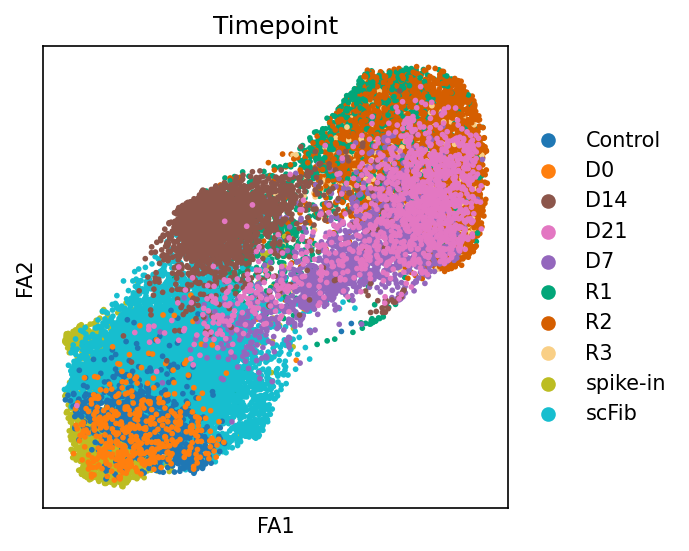

In [7]:
palette = {
    'R1': '#02A679',
    'R2': '#D55E00',
    'R3': '#F9CF86',
    'scFib': '#17BECF',
    'spike-in': '#BCBD22',
    'Control': 'tab:blue',
    'D0': 'tab:orange',
    'D7': 'tab:purple',
    'D14': 'tab:brown',
    'D21': 'tab:pink',
}


plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='group_label',
    palette=palette,
    title='Timepoint',
    frameon=True,
    # legend_loc='none',
    na_color='#DFDFDF',
)

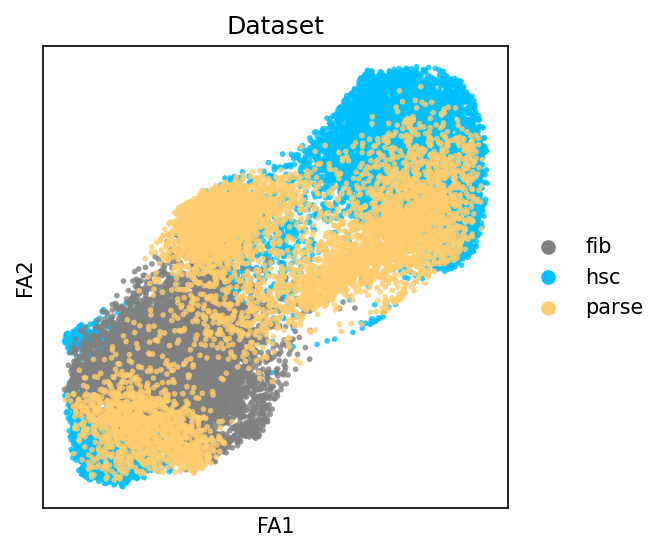

In [9]:
palette = {
    'fib': 'Grey',
    'hsc': 'deepskyblue',
    'parse': '#FECD6F',
}

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='batch',
    palette=palette,
    title='Dataset',
    frameon=True,
    # legend_loc='none',
    na_color='#DFDFDF',
    alpha=0.8,
)

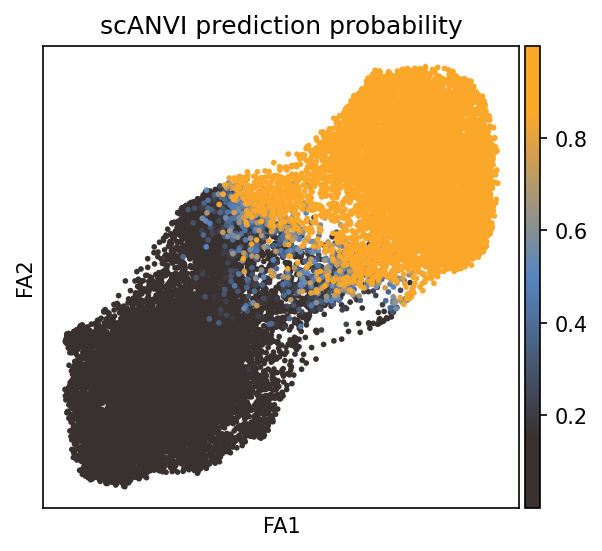

In [10]:
from matplotlib.colors import LinearSegmentedColormap

low = '#39312F' # dark
mid = '#5785C1' # blue
high = '#FBA72A' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)


plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4.5, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='prob_D48_like_cc_covar',
    cmap=custom_cmap,
    title='scANVI prediction probability',
    frameon=True,
)

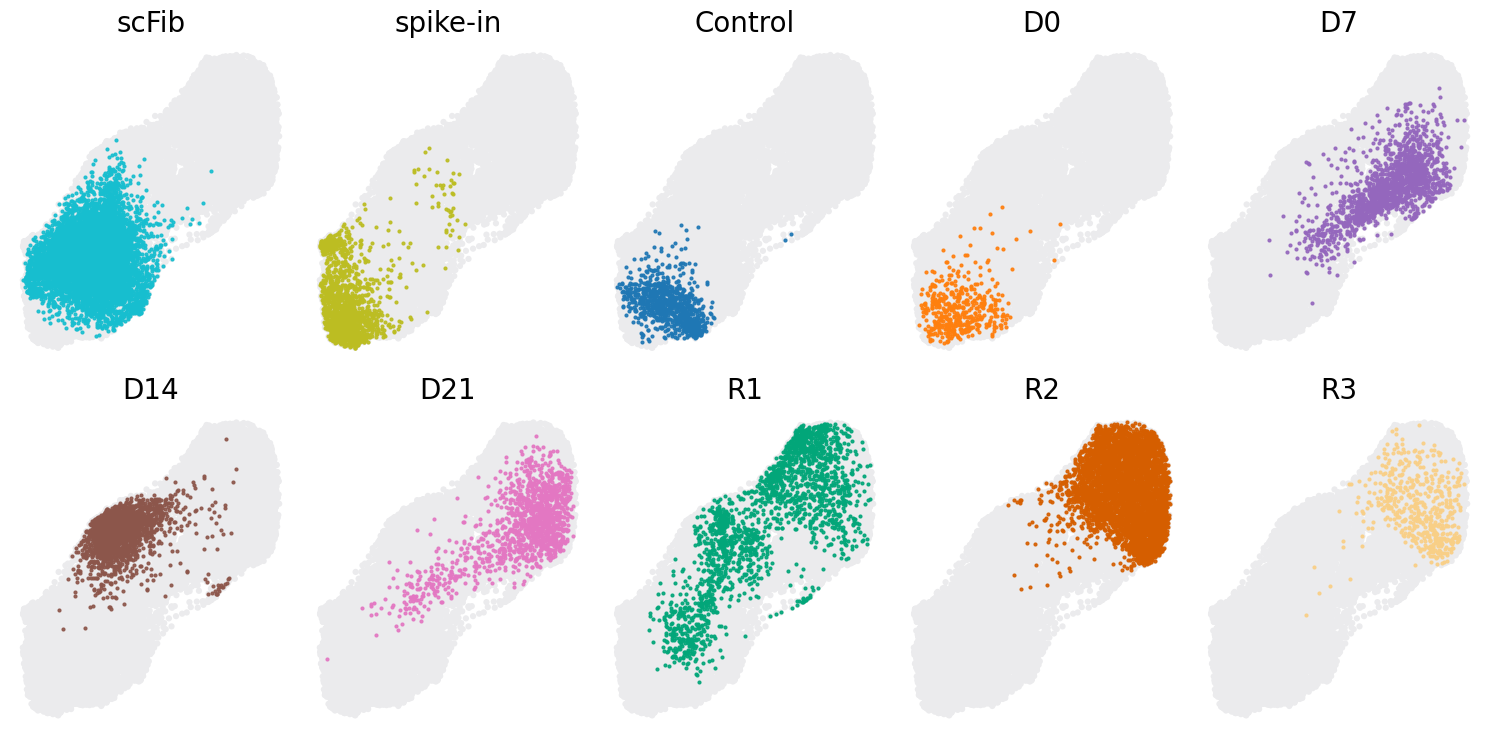

In [11]:
adata.obs['UMAP_1'] = adata.obsm['X_draw_graph_fa'][:, 0] 
adata.obs['UMAP_2'] = adata.obsm['X_draw_graph_fa'][:, 1]

predictions = [
    'scFib', 'spike-in', 'Control', 'D0',
    'D7', 'D14', 'D21',
    'R1', 'R2', 'R3',
]


ncols = 5
nrows = int(np.ceil(len(predictions) / ncols))

plt.rcParams['figure.figsize'] = 15, 7.5
plt.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()

# colors = adata.uns['group_label_colors']
cat = adata.obs['group_label'].cat
color_map = dict(zip(cat.categories, adata.uns['group_label_colors']))


for i, pred in enumerate(predictions):
    ax = axes[i]

    pred_indices = adata.obs['group_label'] == pred

    # Plot background UMAP in grey
    sns.scatterplot(
        data=adata.obs,
        x='UMAP_1',
        y='UMAP_2',
        ec='none',
        s=20,
        color='#EBEBED',#'#DEDEDE',
        ax=ax,
    )

    ax.scatter(
        adata.obs.loc[pred_indices, 'UMAP_1'],
        adata.obs.loc[pred_indices, 'UMAP_2'],
        c=color_map[pred],#colors[i],
        s=4,
        label=pred,
        alpha=0.9,
    )
    
    ax.set_title(predictions[i], fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis(False)

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

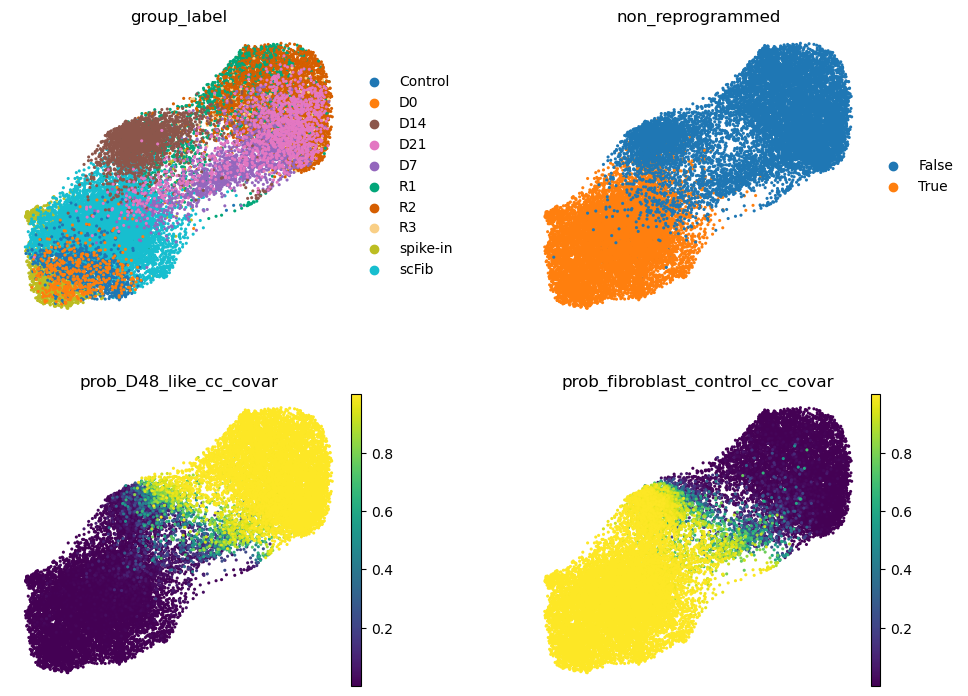

In [12]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=2,
    size=20,
    color=['group_label', 'non_reprogrammed', "prob_D48_like_cc_covar", "prob_fibroblast_control_cc_covar"],
    frameon=False,
    wspace=0.4,
)

In [13]:
df = adata.obs[[
    'batch', 'group_label', 'phase',
    'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar',
]].copy()

print(df.shape)
df.head()

(21491, 6)


,batch,group_label,phase,scanvi_prediction_cc_covar,prob_D48_like_cc_covar,prob_fibroblast_control_cc_covar
AAACCCAAGGTTACCT-1_hsc,hsc,R2,G1,D48_CD34pos_HSC_like,0.997752,0.002248
AAACCCAAGTTGAAGT-1_hsc,hsc,R2,G1,D48_CD34pos_HSC_like,0.998592,0.001408
AAACCCAAGTTGTCGT-1_hsc,hsc,spike-in,S,Fibroblast_control,0.000383,0.999617
AAACCCACAGAAGCGT-1_hsc,hsc,spike-in,G1,Fibroblast_control,0.000045,0.999955
AAACCCACAGGAGGTT-1_hsc,hsc,R2,G1,D48_CD34pos_HSC_like,0.999607,0.000393


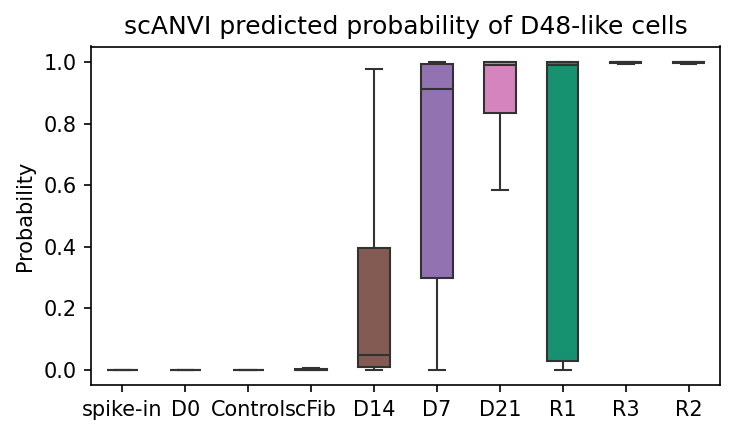

In [14]:
order = (
    df.groupby('group_label', observed=True)['prob_D48_like_cc_covar']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(5,3), dpi=150)

sns.boxplot(
    df,
    x='group_label',
    y='prob_D48_like_cc_covar',
    hue='group_label',
    order=order,
    palette=adata.uns['group_label_colors'],
    showfliers=False,
    width=0.5,
)

plt.xlabel('')
plt.ylabel('Probability')
plt.title('scANVI predicted probability of D48-like cells')

plt.tight_layout()
plt.show()

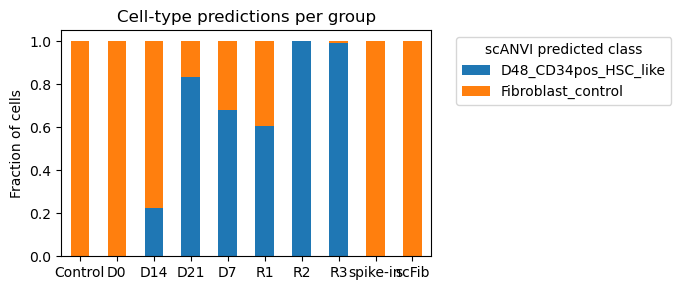

In [15]:
count_df = (
    df.groupby(["group_label", "scanvi_prediction_cc_covar"], observed=True)
      .size()
      .reset_index(name="n_cells")
)

count_pivot = count_df.pivot(
    index="group_label",
    columns="scanvi_prediction_cc_covar",
    values="n_cells"
).fillna(0)


prop_pivot = count_pivot.div(count_pivot.sum(axis=1), axis=0)

prop_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 3)
)

plt.xlabel("")
plt.ylabel("Fraction of cells")
plt.title("Cell-type predictions per group")
plt.xticks(rotation=0)

plt.legend(
    title="scANVI predicted class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

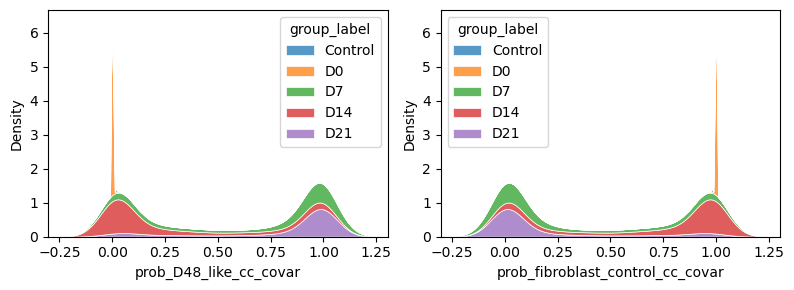

In [16]:
tmp = df[df['batch'] == 'parse'].copy()
tmp['group_label'] = tmp['group_label'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(8,3), dpi=100)

plot_cols = ['prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar']

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    sns.kdeplot(
        tmp,
        x=col,
        hue='group_label',
        multiple='stack',
        ax=ax,
        ec='white',
        lw=0.5,
    )
    
    
plt.tight_layout()
plt.show()

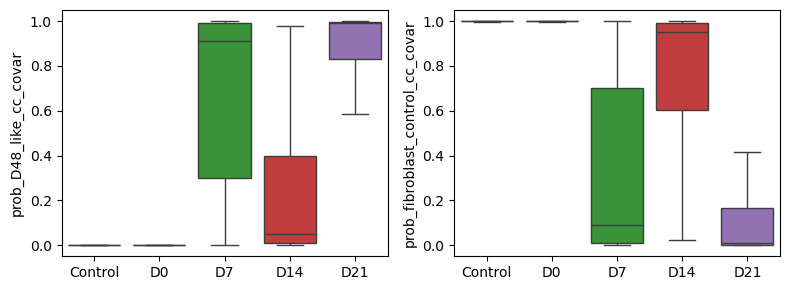

In [18]:
tmp = df[df['batch'] == 'parse'].copy()
tmp['group_label'] = tmp['group_label'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(8,3), dpi=100)

plot_cols = ['prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar']

for i, col in enumerate(plot_cols):
    ax = axes[i]

    sns.boxplot(
        tmp,
        x='group_label',
        y=col,
        hue='group_label',
        showfliers=False,
        ax=ax,
    )
    ax.set_xlabel('')
    
plt.tight_layout()
plt.show()

# Pseudotime test

In [19]:
def find_closest_cell(adata, obs_key='phase', value='G1', obsm_key='X_pca', dataset=None):
    """
    Find the cell closest to a median vector in PCA space for a given group and optional dataset.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group.
        value (str): The value for aggregation (e.g., 'G1').
        obsm_key (str): Key in adata.obsm for PCA or other embedding (e.g., 'X_pca').
        dataset (str, optional): Name of dataset in adata.obs['dataset'] to restrict search.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest matching cell in adata.obs_names.
    """
    mask = adata.obs[obs_key] == value
    if dataset is not None:
        mask &= adata.obs['batch'] == dataset

    emb = adata.obsm[obsm_key][mask]
    
    if emb.shape[0] == 0:
        raise ValueError("No cells match the specified filters.")

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index

In [20]:
bdata = adata.copy()
bdata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden', 'UMAP_1', 'UMAP_2'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_co

03_37_48 16374


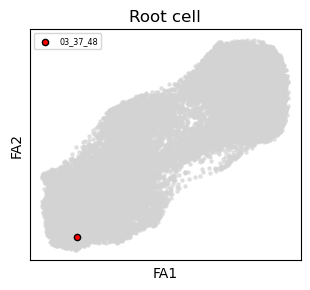

In [21]:
cell_id, root_idx = find_closest_cell(bdata, obs_key='group_label', value='D0', obsm_key='X_scANVI_cc_covar')

print(cell_id, root_idx)

umap = bdata.obsm["X_draw_graph_fa"]
x, y = umap[:, 0], umap[:, 1]

# Plot all cells
plt.figure(figsize=(3.5, 3))
plt.scatter(x, y, s=5, color='lightgray', alpha=0.6)

# Highlight your cell
plt.scatter(x[root_idx], y[root_idx], s=20, color='red', edgecolor='black', label=cell_id)


ax = plt.gca()

ax.tick_params(
    axis='both',
    labelbottom=False, bottom=False,
    labelleft=False, left=False,
)

plt.xlabel("FA1")
plt.ylabel("FA2")
plt.legend(fontsize='xx-small')
plt.title("Root cell")
plt.show()

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9831108  0.95280695 0.9459831  0.944794   0.9314645
     0.92626834 0.92357725 0.91879004 0.91503596 0.9149028  0.90877706
     0.90390646 0.90048087 0.8967048 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


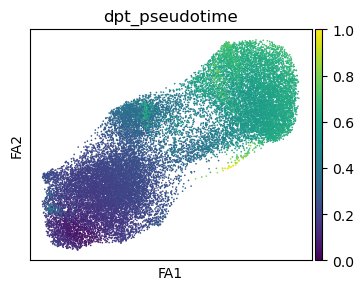

In [22]:
bdata.uns["iroot"] = root_idx

sc.tl.diffmap(bdata)
sc.tl.dpt(bdata)
    
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 4, 3

sc.pl.draw_graph(bdata, color='dpt_pseudotime', color_map='viridis')

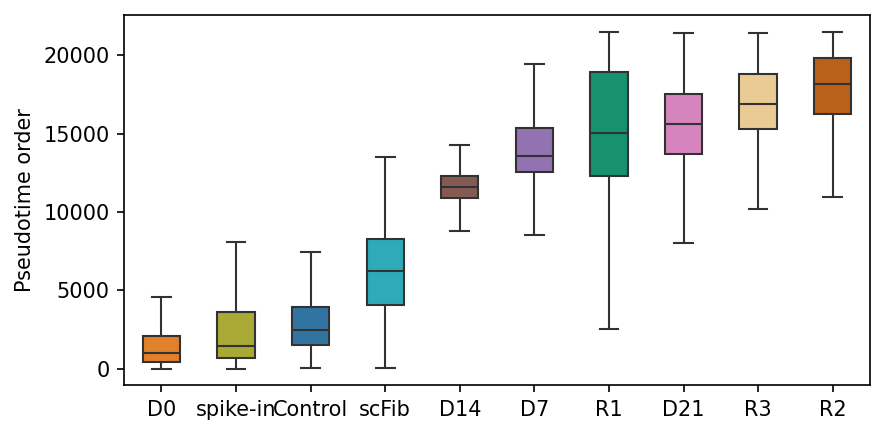

In [23]:
df = bdata.obs[['batch', 'condition_group_wTD', 'dpt_pseudotime', 'group_label']].copy()
df['dpt_rank'] = df['dpt_pseudotime'].rank(ascending=True, method='min').astype(int)

order = (
    df.groupby('group_label', observed=True)['dpt_rank']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(6,3), dpi=150)

sns.boxplot(
    df,
    x='group_label',
    y='dpt_rank',
    hue='group_label',
    order=order,
    palette=bdata.uns['group_label_colors'],
    showfliers=False,
    width=0.5,
)

plt.xlabel('')
plt.ylabel('Pseudotime order')

plt.tight_layout()
plt.show()